<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/iLogos/logo_novafct.png" width="200">

# Departamento de Engenharia Mecânica e Industrial
## Mecânica dos Sólidos II

## Tensões tangenciais em vigas

### Problema 1

Considere a viga fabricada com um perfil tubular, com dimensões transversais 60 $\times$ 80 mm $^2$ e com 8 mm de espessura, que está indicada na figura. No ponto C está aplicada a força $P_1$ = 5 kN numa direção paralela ao eixo $x$, no ponto D está aplicada a força $P_2$ = 15 kN também numa direção paralela ao eixo $x$ e no ponto A, a força $P_3$ = 10 kN numa direção paralela e em sentido oposto ao eixo $y$.

**a)** Determine a distribuição de tensões normais na secção que dista 250 mm da extremidade da viga, com a posição do eixo neutro e os valores da tensão normal máxima e mínima.

**b)** Obtenha o tensor das tensões nos pontos E, F, G e H localizados na secção referida na alínea a) e para o sistema de eixos indicado.

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/Notebooks/Au06/P1/MSII_Au06_P1.png"
width="600">


### Método de Análise

Embora existam várias formas de analisar uma estrutura submetida a cargas combinadas, o procedimento geralmente inclui os seguintes passos:

1. Selecionar um ponto na estrutura onde as tensões devem ser determinadas. Geralmente, o ponto é selecionado numa secção transversal onde as tensões são elevadas, como acontece numa secção transversal onde o momento fletor atinge seu valor máximo.

2. Para cada carga na estrutura, determinar os esforços internos na secção transversal que contém o ponto selecionado. Estes esforços comtém o esforço axial, os esforços tranversos, os momentos fletores e o momento de torsão em relação ao referencial cartesiano principal de inércia.

3. Calcular as tensões normais e de corte no ponto selecionado devido a cada um dos esforços internos resultantes. As tensões são encontradas a partir das fórmulas de tensão derivadas para a flexão e torção de elementos elásticos: por exemplo, $σ = \frac{P}{A}$, $\tau = \frac{T}{2A_0t}$, $σ = \frac{My}{I}$, $τ = \frac{VQ}{Ib}$.

4. Combinar as componentes de tensão para obter o tensor da tensões no ponto selecionado, levando em consideração os sentidos positivos para esta componentes em relação aos eixos de um sistema de coordenadas.

5. Pode-se posteriormente determinar as tensões principais e as tensões máximas de corte no ponto selecionado usando as equações de transformação do tensor das tensões.

6. Determine as deformações no ponto recorrendo a leis constitutiva do material.

### Sistema força-binário equivalente

- Membro ABDE submetido a um sistema de forças.
- Diagrama de corpo livre do segmento ABC, usado para determinar as forças internas e momentos na secção transversal C.
- Forças e momentos internos separados em: (a) as forças e momentos que geram tensões normais e (b)forças e momentos que tão origem a tensões de corte.


<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/Notebooks/Au06/P1/FBequivalente.png"
width="600">

### Resolução

#### **a)** Determine a distribuição de tensões normais na secção que dista 250 mm da extremidade da viga, com a posição do eixo neutro e os valores da tensão normal máxima e mínima.

In [235]:
import numpy as np
import sympy as sy
from sympy.solvers import solve
import matplotlib.pyplot as plt
import os

cor = '2'
if cor == '1':
    plt.rcParams['axes.facecolor'] = (.15, .15, .15)
    plt.rcParams['figure.facecolor'] = (.15, .15, .15)
    plt.rcParams['font.family'] = 'monospace'
    plt.rcParams['font.size'] = 18
    # plt.rcParams['text.usetex'] = True
    params = {"ytick.color" : (.8, .8, .8),
              "xtick.color" : (.8, .8, .8),
              "grid.color" : (.2, .2, .2),
              "text.color" : (.7, .7, .7),
              "axes.labelcolor" : (.8, .8, .8),
              "axes.edgecolor" : (.15, .15, .15)}
else:
    plt.rcParams['axes.facecolor'] = (.7, .7, .7)
    plt.rcParams['figure.facecolor'] = (.7, .7, .7)
    plt.rcParams['font.family'] = 'monospace'
    plt.rcParams['font.size'] = 18
    # plt.rcParams['text.usetex'] = True
    params = {"ytick.color" : (.1, .1, .1),
              "xtick.color" : (.1, .1, .1),
              "grid.color" : (.2, .2, .2),
              "text.color" : (.1, .1, .1),
              "axes.labelcolor" : (.1, .1, .1),
              "axes.edgecolor" : (.15, .15, .15)}
plt.rcParams.update(params)

# data structure, units: N, mm, MPa

class varin: pass

d = varin()

d.tub_b = 60.*1e-3  # unit: m
d.tub_h = 80.*1e-3 # unit: m
d.tub_e = 8.*1e-3 # unit: m
d.xL = 250.e-3 # unit: m
d.P1 = 5.*1e3 # unit: N/m
d.P2 = 15.*1e3 # unit: N/m
d.P3 = 10.*1e3 # unit: N/m

#### Esforço internos

- Convenção de sinais positivos num corte à esquerda:

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/Notebooks/Au06/P1/ConvSinaisPositivosEsq.png"
width="300">

- Diagrama de corpo livre ($N,V_z,V_z,M_x,M_y,M_z$)

Considere-se um troço da viga, seccionada a uma distância de 250 mm da face onde as forças externas são aplicadas. Nessa secção interna, exposta pelo corte da secção, surgem esforços (resultante das forças e momentos: $N,V_z,V_z,M_x,M_y,M_z$) que equilibram o carregamento aplicado. A análise pode fazer-se pelo método das secções, considerando a convenção de esforços ilustrada em Apêndice. Neste caso analisa-se o equilíbrio do diagrama de corpo livre resultante do corte da secção.

Analise-se de seguida o equilíbrio estáticas das forças.

- Esforço axial, $N$

\begin{equation*}
\rightarrow  (+) :: ~
\sum F_x = 0
\quad\Leftrightarrow\quad
P_1 + P_2 - N(x) = 0
\end{equation*}

In [236]:
N = d.P1 + d.P2
print(f'N = {N:.1f} [N]')

N = 20000.0 [N]


- Esforço transverso na direção $y$, $V_y$

\begin{equation*}
\uparrow (+)::~
\sum F_y = 0
\quad\Leftrightarrow\quad
- P_3 + V_y(x) = 0
\end{equation*}

In [237]:
Vy = d.P3
print(f'Vy = {Vy:.1f} [N]')

Vy = 10000.0 [N]


- Esforço transverso na direção $z$, $V_z$

\begin{equation*}
\swarrow (+):: ~
\sum F_z = 0
\quad\Leftrightarrow\quad
V_z(x) = 0
\end{equation*}

In [238]:
Vz = 0
print(f'Vz = {Vz:.1f} [N]')

Vz = 0.0 [N]


- Momento torsor em torno do eixo $x$, $M_x(\equiv T)$

Genericamente, o momento de uma força é obtido pelo produto vetorial entre o vetor posição $\vec{r}_{Ci}$ e o vetor força $\vec{P}_i$. Só exercem momento segundo a direção $x$ as quantidades que estão contidas num plano perpendicular ao eixo dos $x$. Neste caso apenas a força vertical $\vec{P}_3$ exerce momento em $x$.

\begin{equation*}
\circlearrowleft (+) :: ~
\sum M_x = 0
\quad\Leftrightarrow\quad
- P_3 \cdot (b/2) + M_x(x) = 0
\end{equation*}

com $\vec{P}_3 = -P_3~\vec{\jmath} ~\wedge~\vec{r}_{\vec{P_3}} = -b/2~\vec{k} \quad\therefore\quad \vec{M_x}^{P_3} = - P_3 (b/2)~\vec{\imath}$

In [239]:
Mx = d.P3*d.tub_b/2
print(f'Mx = {Mx:.1f} [N.m]')

Mx = 300.0 [N.m]


- Momento fletor em torno do eixo $y$, $M_y$

Por definição de momento de uma força, só exercem momento de flexão em relação ao eixo $y$, as forças que são coplanares com o plano $x-z$ que lhe é perpendicular. Neste caso, ambas as forças $\vec{P}_1$ e $\vec{P}_2$ contribuem para $M_y$.

\begin{equation*}
\circlearrowleft (+) :: ~
\sum M_y = 0
\quad\Leftrightarrow\quad
P_1 \cdot b/2 - P_2 \cdot b/2 - M_y(x) = 0
\end{equation*}

com

- $\vec{P}_1 = P_1~\vec{\imath} ~\wedge~\vec{r}_{\vec{P_1}} = b/2~\vec{k} \quad\therefore\quad P_1 (b/2)~\vec{\jmath}$
- $\vec{P}_2 = P_2~\vec{\imath} ~\wedge~\vec{r}_{\vec{P_2}} = -b/2~\vec{k} \quad\therefore\quad -P_2 (b/2)~\vec{\jmath}$

In [240]:
My = d.P1*d.tub_b/2 - d.P2*d.tub_b/2
print(f'My = {My:.1f} [N.m]')

My = -300.0 [N.m]


- Momento fletor em torno do eixo $z$, $M_z$

Nesta análise, todas as forças exercem momento fletor segundo o eixo $z$, pois $\vec{P}_1$, $\vec{P}_2$ e $\vec{P}_3$ estão orientadas no plano $x-y$, perpendicular a $z$.

\begin{equation*}
\circlearrowleft (+) :: ~
\sum M_z = 0
\quad\Leftrightarrow\quad
P_1 \cdot h/2 + P_2 \cdot h/2 - P_3 \cdot x_L - M_z(x) = 0
\end{equation*}

com

- $\vec{P}_1 = P_1~\vec{\imath} ~\wedge~\vec{r}_{\vec{P_1}} = -h/2~\vec{\jmath} \quad\therefore\quad P_1 (h/2)~\vec{k}$
- $\vec{P}_2 = P_2~\vec{\imath} ~\wedge~\vec{r}_{\vec{P_2}} = -h/2~\vec{k} \quad\therefore\quad P_2 (h/2)~\vec{k}$
- $\vec{P}_3 = -P_3~\vec{\jmath} ~\wedge~\vec{r}_{\vec{P_2}} = x_L~\vec{\imath} \quad\therefore\quad - P_3 x_L~\vec{k}$

In [241]:
Mz = d.P1*d.tub_h/2 + d.P2*d.tub_h/2 - d.P3*d.xL
print(f'Mz = {Mz:.1f} [N.m]')

Mz = -1700.0 [N.m]


#####  Esforços resultantes:

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/Notebooks/Au06/P1/EsforcosResultantes.png"
width="300">

Depois da análise do equilíbrio de forças estático, determinem-se as propriedades de área da secção:

- Área da secção

In [242]:
A = d.tub_b*d.tub_h - (d.tub_b-2*d.tub_e)*(d.tub_h-2*d.tub_e)
print(f'A = {A:.3e} [m^2]')

A = 1.984e-03 [m^2]


- Momento de inércia em relação ao eixo $z$, $I_z$

Nota: na expressão $I_i = bh³/12$, a dimensão ao cubo ($h³$) é sempre uma dimensão perpendicular ao eixo em análise $i$.

In [243]:
def irect(b,h): return b*h**3/12

Iz = irect(d.tub_b,d.tub_h) - irect(d.tub_b-2*d.tub_e,d.tub_h-2*d.tub_e)
print(f'Iz = {Iz:.3e} [m^2]')

Iz = 1.599e-06 [m^2]


- Momento de inércia em relação ao eixo $y$, $I_y$

In [244]:
Iy = irect(d.tub_h,d.tub_b) - irect(d.tub_h-2*d.tub_e,d.tub_b-2*d.tub_e)
print(f'Iy = {Iy:.3e} [m^2]')

Iy = 9.857e-07 [m^2]


#### Esforço combinado

Neste cenário de carregamento excêntrico, pelo princípio de Saint-Venant, as tensões normais numa secção suficientemente afastada das extremidades da barra (devido a efeitos de concentração local de tensões) podem ser calculadas, atendendo ainda ao princípio da sobreposição, por:

\begin{equation*}
\sigma_{xx} = \frac{N}{A} + \frac{M_z}{I_z}y - \frac{M_y}{I_y} z
\end{equation*}

De notar que os sinais desta expressão são válidos considerando $N$, $M_z$ e $M_y$ positivos em relação ao eixo principal de inércia da secção.

In [245]:
def printsymSF(expr):
    expr2 = sy.simplify(sy.factor(expr))
    return expr2.xreplace({n : round(n, 3) for n in expr2.atoms(sy.Number)})

y, z, sigx = sy.symbols('y z sigx')

sec_hand_expr = N/A - Mz/Iz*y + My/Iy*z
Eq = sigx - sec_hand_expr
sigxx = solve(Eq,sigx)[0]
print(f'sigxx(y,z)  = {printsymSF(sigxx*1e-6)} [MPa]')

sigxx(y,z)  = 1063.294*y - 304.357*z + 10.081 [MPa]


y = 0.286239541267118*z - 0.00948058191018342 (recta geométrica do eixo neutro) [m]
z = 3.49357742670082*y + 0.0331211469534049 (recta geométrica do eixo neutro) [m]


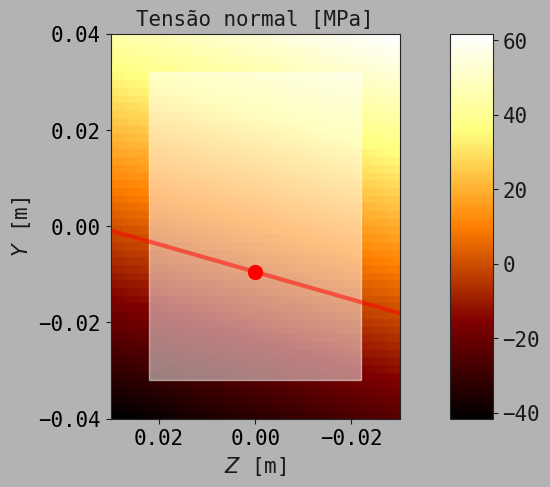

In [246]:
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.patches import Rectangle

zsiz = np.linspace(d.tub_b/2,-d.tub_b/2)
ysiz = np.linspace(d.tub_h/2,-d.tub_h/2)
Z, Y = np.meshgrid(zsiz, ysiz)

def tensnormal(y2,z2):
    return sigxx.subs({(y,y2),(z,z2)}) #- eval_NAB/A - eval_MzAB/Iz*y + eval_MyAB/Iy*z

SxxMap = np.zeros(np.shape(Z))
for i in range(0,len(ysiz)):
    for j in range(0,len(zsiz)):
        SxxMap[i,j] = tensnormal(ysiz[i],zsiz[j])

yzfun = solve(sigxx,y)[0]
print(f'y = {yzfun} (recta geométrica do eixo neutro) [m]')
print(f'z = {solve(sigxx,z)[0]} (recta geométrica do eixo neutro) [m]')

zplo = zsiz
yplo = np.zeros(len(zplo))
for i in range(0,len(zplo)):
    yplo[i] = yzfun.subs(z,zplo[i])

fzp = 15
# Visualizacao u1(X1,X2,X3,t1)
fig = plt.figure(figsize=(10, 5))
ax  = plt.gca()
ttl = plt.title('Tensão normal [MPa]',fontsize=15)
ttl.set_position([0.5, 1.05])
plt.ylabel(r'$Y$ [m]',fontsize=fzp)
plt.xlabel(r'$Z$ [m]',fontsize=fzp)
im = ax.imshow(SxxMap*1e-6, extent=[d.tub_b/2, -d.tub_b/2, -d.tub_h/2,d.tub_h/2], cmap="afmhot")
ax.add_patch(Rectangle((-d.tub_b/2+d.tub_e, -d.tub_h/2+d.tub_e), d.tub_b-2*d.tub_e, d.tub_h-2*d.tub_e,color="white",alpha=0.5))
plt.plot(zplo,yplo,'r-',linewidth=3,alpha=0.5)
ax.plot(0,yzfun.subs(z,0),'or',markersize=10)
plt.xticks(color ='k', size=fzp)
plt.yticks(color ='k', size=fzp)
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="15%", pad=0.5)
cbar = plt.colorbar(im, cax=cax, orientation = "vertical")
cbar.ax.tick_params(labelsize=fzp)
plt.show()

In [247]:
ymax_, zmax_ = d.tub_h/2, -d.tub_b/2
sigmax_ = tensnormal(ymax_,zmax_)
print(f'sig.max :: ({ymax_},{zmax_}) :: {sigmax_*1e-6:.2f} [MPa]')

ymin_, zmin_ = -d.tub_h/2, d.tub_b/2
sigmin_ = tensnormal(ymin_,zmin_)
print(f'sig.min :: ({ymin_},{zmin_}) :: {sigmin_*1e-6:.2f} [MPa]')

sig.max :: (0.04,-0.03) :: 61.74 [MPa]
sig.min :: (-0.04,0.03) :: -41.58 [MPa]


#### **b)** Obtenha o tensor das tensões nos pontos E, F, G e H localizados na secção referida na alínea a) e para o sistema de eixos indicado.

In [248]:
yE, zE = d.tub_h/2, 0
sigE = tensnormal(yE, zE)
print(f'sig.E :: ({yE},{zE}) :: {sigE*1e-6:.2f} [MPa]')

yF, zF = 0, d.tub_b/2
sigF = tensnormal(yF, zF)
print(f'sig.F :: ({yF},{zF}) :: {sigF*1e-6:.3f} [MPa]')

yG, zG = -d.tub_h/2, 0
sigG = tensnormal(yG, zG)
print(f'sig.G :: ({yG},{zG}) :: {sigG*1e-6:.2f} [MPa]')

yH, zH = 0, -d.tub_b/2
sigH = tensnormal(yH, zH)
print(f'sig.G :: ({yH},{zH}) :: {sigH*1e-6:.2f} [MPa]')

sig.E :: (0.04,0) :: 52.61 [MPa]
sig.F :: (0,0.03) :: 0.950 [MPa]
sig.G :: (-0.04,0) :: -32.45 [MPa]
sig.G :: (0,-0.03) :: 19.21 [MPa]


- Tensor das tensões num ponto material:

\begin{equation*}
[\sigma] =
\begin{bmatrix}
\sigma_{xx} & \tau_{xy} & \tau_{xz} \\
\tau_{xy} & \sigma_{yy} & \tau_{yz} \\
\tau_{xz} & \tau_{yz} & \sigma_{zz}
\end{bmatrix}
\end{equation*}

No problema de flexão em estudo apenas existem tensões normais segundo a direção $x~:~\sigma_{xx}=N/A~,~\sigma_{yy}=\sigma_{zz}=0$.

A superfície em análise é perpendicular ao eixo longidutinal $x$ pelo que $\tau_{yz} = 0$, resultando:

\begin{equation*}
[\sigma] =
\begin{bmatrix}
\sigma_{xx} & \tau_{xy} & \tau_{xz} \\
\tau_{xy} & 0 & 0 \\
\tau_{xz} & 0 & 0
\end{bmatrix}
\end{equation*}

Acima já se determinaram as componentes de tensão normal, $\sigma_{xx}$, para cada ponto enunciado do perfil (E,F,G,H).

Resta-nos determinar as componentes de tensão de corte para esses pontos. De notar que:

- $T, V_y \longrightarrow \tau_{xy}$
- $T, (V_z = 0) \longrightarrow \tau_{xz}$

####  Sistema de força-binário equivalente

Importa salientar que, para a análise das componentes de tensão de corte originadas pelos esforços transversais $V_y$ e $V_z$, bem como pelo momento de torção, $M_x \equiv T$, geralmente é mais conveniente considerar a resultante dos esforços internos como resultante do sistema de força-binário equivalente às forças externas.

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/Notebooks/Au06/P1/MSII_Au06_P1.png"
width="300">

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/Notebooks/Au06/P1/FBEquiv.png"
width="600">

####  Análise da tensão de corte devida à torção

Sentido positivo para o momento torsor:


<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/Notebooks/Au06/P1/TorcaoPositiva.png"
width="300">

O momento de torção $T$ da secção da direita, com sentido positivo numa rotação de $z$ para $y$, induz tensões de corte: (1) nos ramos verticais, $\tau_{xy}$ (o primeiro índice indica a superfície perpendicular ao eixo $x$ e o segundo índice indica a direção da força tangente em $y$); (2) nos troços horozontais, $\tau_{xz}$.

A tensão de corte média resultante do momento torsor, $\tau$, é dada por:

\begin{equation*}
\tau_{xy} = \tau_{xz} \equiv \tau = \frac{T}{2A_0t}
\quad\wedge\quad T \equiv M_x
\end{equation*}

onde, $A_0$ é a área interna definida pelo contorno da linha central da parede do perfil e $t$ é a espessura da parede do perfil tubular.

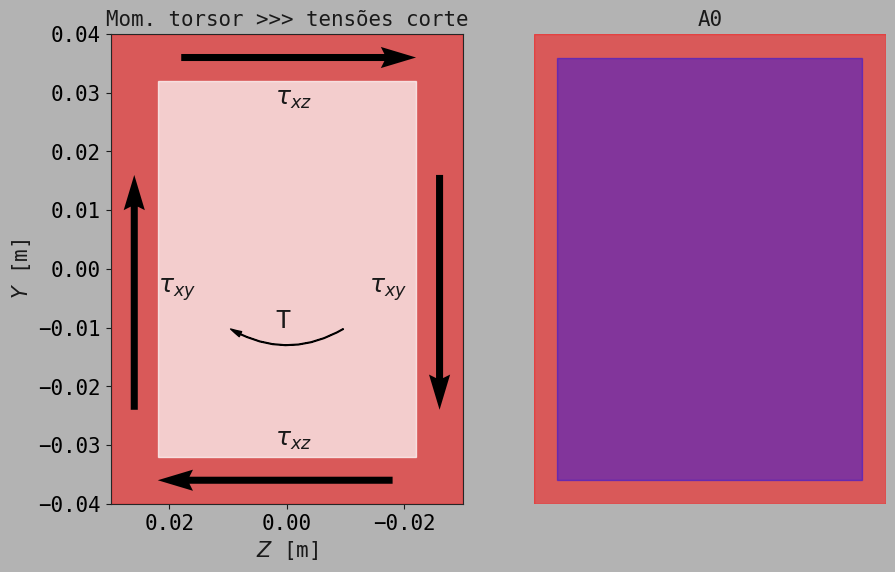

In [249]:
import matplotlib.patches as patches

fig = plt.figure(figsize=(10, 7))
plt.subplot(1, 2, 1)
ax  = plt.gca()
ttl = plt.title('Mom. torsor >>> tensões corte',fontsize=15)
ttl.set_position([0.5, 1.05])
plt.ylabel(r'$Y$ [m]',fontsize=fzp)
plt.xlabel(r'$Z$ [m]',fontsize=fzp)
ax.add_patch(Rectangle((d.tub_b/2, -d.tub_h/2), -d.tub_b, d.tub_h,color="red",alpha=0.5))
ax.add_patch(Rectangle((d.tub_b/2-d.tub_e, -d.tub_h/2+d.tub_e), -d.tub_b+2*d.tub_e, d.tub_h-2*d.tub_e,color="white",alpha=0.7))
plt.xticks(color ='k', size=fzp)
plt.yticks(color ='k', size=fzp)
cbar.ax.tick_params(labelsize=fzp)
plt.xlim([d.tub_b/2,-d.tub_b/2])
plt.ylim([-d.tub_h/2,d.tub_h/2])
ax.set_aspect('equal', 'box')

x_pos, y_pos = d.tub_b/2-d.tub_e/2, -3*d.tub_e
x_direct, y_direct = 0, 1
ax.quiver(x_pos, y_pos, x_direct, y_direct, scale = 1.5, width=.02)
plt.text(x_pos-d.tub_e/2, y_pos+2.5*d.tub_e, r"$\tau_{xy}$")

x_pos, y_pos = -d.tub_b/2+d.tub_e/2, 2*d.tub_e
x_direct, y_direct = 0, -1
ax.quiver(x_pos, y_pos, x_direct, y_direct, scale = 1.5, width=.02)
plt.text(x_pos+14*d.tub_e/4, y_pos+1.5*d.tub_e, r"$\tau_{xz}$")

x_pos, y_pos = d.tub_b/2-1.5*d.tub_e, d.tub_h/2-d.tub_e/2
x_direct, y_direct = 1, 0
ax.quiver(x_pos, y_pos, x_direct, y_direct, scale = 1.5, width=.02)
plt.text(x_pos-4*d.tub_e, y_pos-5*d.tub_e, r"$\tau_{xy}$")

x_pos, y_pos = -d.tub_b/2+1.5*d.tub_e, -d.tub_h/2+d.tub_e/2
x_direct, y_direct = -1, 0
ax.quiver(x_pos, y_pos, x_direct, y_direct, scale = 1.5, width=.02)
plt.text(x_pos+2.5*d.tub_e, y_pos+.75*d.tub_e, r"$\tau_{xz}$")

style = "Simple, tail_width=0.5, head_width=4, head_length=8"
kw = dict(arrowstyle=style, color="k")

c = patches.FancyArrowPatch((-0.01, -0.01), (0.01, -0.01),
                             connectionstyle="arc3,rad=-.3", **kw)
plt.text(0.002, -0.01,"T")
plt.gca().add_patch(c)

plt.subplot(1, 2, 2)
ax  = plt.gca()
ttl = plt.title('A0',fontsize=15)
ttl.set_position([0.5, 1.05])
plt.axis('off')
ax.add_patch(Rectangle((d.tub_b/2, -d.tub_h/2), -d.tub_b, d.tub_h,color="red",alpha=0.5))
ax.add_patch(Rectangle((d.tub_b/2-d.tub_e/2, -d.tub_h/2+d.tub_e/2), -d.tub_b+d.tub_e, d.tub_h-d.tub_e,color="blue",alpha=.4))
plt.xticks(color ='k', size=fzp)
plt.yticks(color ='k', size=fzp)
cbar.ax.tick_params(labelsize=fzp)
plt.xlim([d.tub_b/2,-d.tub_b/2])
plt.ylim([-d.tub_h/2,d.tub_h/2])
ax.set_aspect('equal', 'box')
plt.show()

In [250]:
tor_A0 = (d.tub_h-d.tub_e)*(d.tub_b-d.tub_e)
print(f'tor_A0 = {tor_A0:.3e} [m²]')
tor_t = d.tub_e
print(f'tor_t = {tor_t:.3f} [m]')
tor_tau = np.abs(Mx)/2/tor_A0/tor_t
print(f'tor_tau = {tor_tau*1e-6:.3f} [MPa]')

tor_A0 = 3.744e-03 [m²]
tor_t = 0.008 [m]
tor_tau = 5.008 [MPa]


De notar que o momento torsor externo será localmente equilibrado: (1) nos troços horizontais do perfil, por tensões de corte $\tau_{xz}$ que têm sentido negativo no ponto E e sentido positivo no ponto G; (2) nos tramos verticais, por tensões de corte $\tau_{xy}$ que têm sentido positivo no ponto F e sentido negativo no ponto H.

####  Análise da tensão de corte devida ao esforço transverso $V_y$

De notar que o esforço transverso $V_y$ é nulo nos pontos E e G, pelo que interessa analisar a tensão nos pontos F e H dos ramos verticais do perfil.

Do formulário tem-se:

\begin{equation*}
\tau_{xy} = \frac{V_yQ_z}{I_zt}
\quad\wedge\quad Q_z = \int_A^* y\,\mathrm{d}x = A^*\overline{y} = \sum_i A_i^*\overline{y}_i
\end{equation*}

onde, $Q_z$ é o primeiro momento de área (momento estático) em relação ao eixo $z$ de metade de secção (pontos F e H), e $t$ é a espessura resistente ao corte

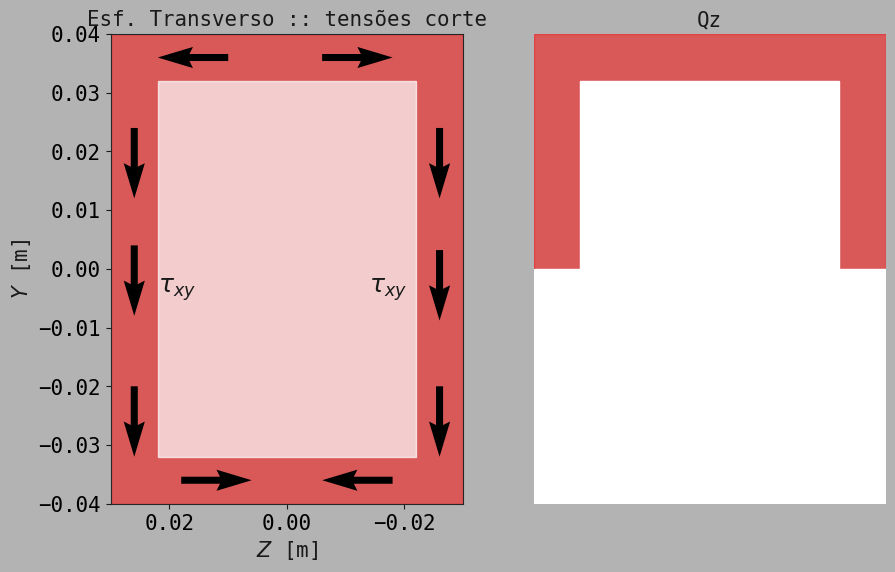

In [251]:
fig = plt.figure(figsize=(10, 7))
plt.subplot(1, 2, 1)
ax  = plt.gca()
ttl = plt.title('Esf. Transverso :: tensões corte',fontsize=15)
ttl.set_position([0.5, 1.05])
plt.ylabel(r'$Y$ [m]',fontsize=fzp)
plt.xlabel(r'$Z$ [m]',fontsize=fzp)
ax.add_patch(Rectangle((d.tub_b/2, -d.tub_h/2), -d.tub_b, d.tub_h,color="red",alpha=0.5))
ax.add_patch(Rectangle((d.tub_b/2-d.tub_e, -d.tub_h/2+d.tub_e), -d.tub_b+2*d.tub_e, d.tub_h-2*d.tub_e,color="white",alpha=0.7))
plt.xticks(color ='k', size=fzp)
plt.yticks(color ='k', size=fzp)
cbar.ax.tick_params(labelsize=fzp)
plt.xlim([d.tub_b/2,-d.tub_b/2])
plt.ylim([-d.tub_h/2,d.tub_h/2])
ax.set_aspect('equal', 'box')

x_pos, y_pos = d.tub_b/2-d.tub_e/2, -2.5*d.tub_e
x_direct, y_direct = 0, -1
ax.quiver(x_pos, y_pos, x_direct, y_direct, scale = 5, width=.02)
plt.text(x_pos-d.tub_e/2, y_pos+2.*d.tub_e, r"$\tau_{xy}$")
x_pos, y_pos = d.tub_b/2-d.tub_e/2, .5*d.tub_e
x_direct, y_direct = 0, -1
ax.quiver(x_pos, y_pos, x_direct, y_direct, scale = 5, width=.02)
x_pos, y_pos = d.tub_b/2-d.tub_e/2, 3.*d.tub_e
x_direct, y_direct = 0, -1
ax.quiver(x_pos, y_pos, x_direct, y_direct, scale = 5, width=.02)

x_pos, y_pos = -d.tub_b/2+d.tub_e/2, 3*d.tub_e
x_direct, y_direct = 0, -1
ax.quiver(x_pos, y_pos, x_direct, y_direct, scale = 5, width=.02)
x_pos, y_pos = -d.tub_b/2+d.tub_e/2, 0.4*d.tub_e
x_direct, y_direct = 0, -1
ax.quiver(x_pos, y_pos, x_direct, y_direct, scale = 5, width=.02)
x_pos, y_pos = -d.tub_b/2+d.tub_e/2, -2.5*d.tub_e
x_direct, y_direct = 0, -1
ax.quiver(x_pos, y_pos, x_direct, y_direct, scale = 5, width=.02)

x_pos, y_pos = d.tub_b/2-2.5*d.tub_e, d.tub_h/2-d.tub_e/2
x_direct, y_direct = -1, 0
ax.quiver(x_pos, y_pos, x_direct, y_direct, scale = 5, width=.02)
x_pos, y_pos = d.tub_b/2-4.5*d.tub_e, d.tub_h/2-d.tub_e/2
x_direct, y_direct = 1, 0
ax.quiver(x_pos, y_pos, x_direct, y_direct, scale = 5, width=.02)
plt.text(x_pos-1*d.tub_e, y_pos-5*d.tub_e, r"$\tau_{xy}$")

x_pos, y_pos = -d.tub_b/2+1.5*d.tub_e, -d.tub_h/2+d.tub_e/2
x_direct, y_direct = -1, 0
ax.quiver(x_pos, y_pos, x_direct, y_direct, scale = 5, width=.02)
x_pos, y_pos = -d.tub_b/2+6*d.tub_e, -d.tub_h/2+d.tub_e/2
x_direct, y_direct = 1, 0
ax.quiver(x_pos, y_pos, x_direct, y_direct, scale = 5, width=.02)

style = "Simple, tail_width=0.5, head_width=4, head_length=8"
kw = dict(arrowstyle=style, color="k")

plt.subplot(1, 2, 2)
ax  = plt.gca()
ttl = plt.title('Qz',fontsize=15)
ttl.set_position([0.5, 1.05])
plt.axis('off')
ax.add_patch(Rectangle((d.tub_b/2, -d.tub_h/2), -d.tub_b, d.tub_h,color="red",alpha=0.5))
ax.add_patch(Rectangle((d.tub_b/2-d.tub_e, -d.tub_h/2+d.tub_e), -d.tub_b+2*d.tub_e, d.tub_h-2*d.tub_e,color="white",alpha=1.))
ax.add_patch(Rectangle((d.tub_b/2, -d.tub_h/2), -d.tub_b, d.tub_h/2,color="white",alpha=1.))
plt.xticks(color ='k', size=fzp)
plt.yticks(color ='k', size=fzp)
cbar.ax.tick_params(labelsize=fzp)
plt.xlim([d.tub_b/2,-d.tub_b/2])
plt.ylim([-d.tub_h/2,d.tub_h/2])
ax.set_aspect('equal', 'box')

plt.show()

In [252]:
yretmaior = d.tub_h/2/2
print(f'---\nyretmaior = {yretmaior:.3f} [m]')
Aretmaior = d.tub_h/2*d.tub_b
print(f'Aretmaior = {d.tub_h/2:.3f} x {d.tub_b:.3f} = {Aretmaior:.3e} [m²]')
Qretmaior = Aretmaior*yretmaior
print(f'Qretmaior = {Qretmaior:.3e} [m³]')
yretmenor = (d.tub_h/2-d.tub_e)/2
print(f'---\nyretmenor = {yretmenor:.3f} [m]')
Aretmenor = (d.tub_h/2-d.tub_e)*(d.tub_b-2*d.tub_e)
print(f'Aretmenor = {d.tub_h/2-d.tub_e:.3f} x {d.tub_b-2*d.tub_e:.3f} = {Aretmenor:.3e} [m²]')
Qretmenor = Aretmenor*yretmenor
print(f'Qretmenor = {Qretmenor:.3e} [m³]')
Qret = Qretmaior - Qretmenor
print(f'---\nQret = {Qretmaior:.3e} - {Qretmenor:.3e} = {Qret:.3e} [m³]')
tau_Vy = Vy*Qret/Iz/(2*d.tub_e)
print(f'::\nVy = {Vy:.3f} [N]')
print(f'Qz = {Qret:.3e} [m³]')
print(f'Iz = {Iz:.3e} [m⁴]')
print(f't  = {2*d.tub_e:.3e} [m]')
print(f'>>> tau_xy_Vy = {tau_Vy*1e-6:.3f} [MPa]')

---
yretmaior = 0.020 [m]
Aretmaior = 0.040 x 0.060 = 2.400e-03 [m²]
Qretmaior = 4.800e-05 [m³]
---
yretmenor = 0.016 [m]
Aretmenor = 0.032 x 0.044 = 1.408e-03 [m²]
Qretmenor = 2.253e-05 [m³]
---
Qret = 4.800e-05 - 2.253e-05 = 2.547e-05 [m³]
::
Vy = 10000.000 [N]
Qz = 2.547e-05 [m³]
Iz = 1.599e-06 [m⁴]
t  = 1.600e-02 [m]
>>> tau_xy_Vy = 9.957 [MPa]


- Tensor das tensões no ponto E, $[\sigma_E]$:

\begin{equation*}
\sigma_{xx}(y_E,z_E)
~\wedge~ \tau_{xy} = 0
~\wedge~ \tau_{xz} = -\frac{T}{2A_0t}
\end{equation*}

Importa notar que no ponto E, o momento de torção tem um sentido negativo em relação ao eixo positivo dos $z$, e que a tensão de corte $\tau_{xz}$ é medida positivamente no sentido positivo de $z$.

Pelo que o tensor das tensões vem:

\begin{equation*}
[\sigma_E] =
\begin{bmatrix}
\sigma_{xx}(y_E,z_E) & 0 & -\displaystyle\frac{T}{2A_0t} \\
0 & 0 & 0 \\
-\displaystyle\frac{T}{2A_0t} & 0 & 0
\end{bmatrix}
\quad\textrm{[MPa]}
\end{equation*}

In [253]:
np.set_printoptions(precision=4)

def tenstens(s11,s12,s13,s22,s23,s33):
    return np.array([[s11,s12,s13],[s12,s22,s23],[s13,s13,s33]], np.float64)

ttE = tenstens(sigE,0,-tor_tau,0,0,0)
print(f"ttE :: \n {np.array2string(ttE*1e-6, precision=2, floatmode='fixed')} [MPa]")

ttE :: 
 [[52.61  0.00 -5.01]
 [ 0.00  0.00  0.00]
 [-5.01 -5.01  0.00]] [MPa]


- Tensor das tensões no ponto G, $[\sigma_G]$:

\begin{equation*}
\sigma_{xx}(y_G,z_G)
~\wedge~ \tau_{xy} = 0
~\wedge~ \tau_{zz} = \frac{T}{2A_0t}
\end{equation*}

Importa notar que no ponto G, o momento de torção tem um sentido positivo em relação ao eixo positivo dos $z$, e, consequentemente, a componente de tensão de corte $\tau_{xz}$ devida ao momento de torção é positiva.

Pelo que o tensor das tensões vem:

\begin{equation*}
[\sigma_G] =
\begin{bmatrix}
\sigma_{xx}(y_G,z_G) & 0 & \displaystyle\frac{T}{2A_0t} \\
0 & 0 & 0 \\
\displaystyle\frac{T}{2A_0t} & 0 & 0
\end{bmatrix}
\quad\textrm{[MPa]}
\end{equation*}

In [254]:
ttG = tenstens(sigG,0,tor_tau,0,0,0)
print(f"ttG :: \n {np.array2string(ttG*1e-6, precision=2, floatmode='fixed')} [MPa]")

ttG :: 
 [[-32.45   0.00   5.01]
 [  0.00   0.00   0.00]
 [  5.01   5.01   0.00]] [MPa]


- Tensor das tensões no ponto F, $[\sigma_F]$:

\begin{equation*}
\sigma_{xx}(y_F,z_F)
~\wedge~ \tau_{xy} = \frac{T}{2A_0t} - \frac{V_yQ_z}{I_zt}
~\wedge~ \tau_{xz} = 0
\end{equation*}

Pelo que o tensor das tensões vem:

\begin{equation*}
[\sigma_F] =
\begin{bmatrix}
\sigma_{xx}(y_F,z_F) & \left(\displaystyle\frac{T}{2A_0t} - \frac{VQ}{I_zt}\right)  & 0\\
\left(\displaystyle\frac{T}{2A_0t} - \frac{VQ}{I_zt}\right)  & 0 & 0 \\
0 & 0 & 0
\end{bmatrix}
\quad\textrm{[MPa]}
\end{equation*}

In [255]:
ttF = tenstens(sigF,tor_tau-tau_Vy,0,0,0,0)
print(f"ttE :: \n {np.array2string(ttF*1e-6, precision=2, floatmode='fixed')} [MPa]")

ttE :: 
 [[ 0.95 -4.95  0.00]
 [-4.95  0.00  0.00]
 [ 0.00  0.00  0.00]] [MPa]


- Tensor das tensões no ponto H, $[\sigma_H]$:

\begin{equation*}
\sigma_{xx}(y_H,z_H)
~\wedge~ \tau_{xy} = -\frac{T}{2A_0t} - \frac{VQ}{I_zt}
~\wedge~ \tau_{xz} = 0
\end{equation*}

Pelo que o tensor das tensões vem:

\begin{equation*}
[\sigma_H] =
\begin{bmatrix}
\sigma_{xx}(y_H,z_H) & \left(-\displaystyle\frac{T}{2A_0t} - \frac{VQ}{I_zt}\right)  & 0\\
\left(-\displaystyle\frac{T}{2A_0t} - \frac{VQ}{I_zt}\right) & 0 & 0 \\
0 & 0 & 0
\end{bmatrix}
\quad\textrm{[MPa]}
\end{equation*}

In [256]:
ttH = tenstens(sigH,-tor_tau-tau_Vy,0,0,0,0)
print(f"ttH :: \n {np.array2string(ttH*1e-6, precision=2, floatmode='fixed')} [MPa]")

ttH :: 
 [[ 19.21 -14.97   0.00]
 [-14.97   0.00   0.00]
 [  0.00   0.00   0.00]] [MPa]


#### Apêndice. Convensão de sinais positivos para os esforços

<img src="https://userweb.fct.unl.pt//~jmc.xavier/MSII/Notebooks/Formulario/PosSignConv.jpg"
width="800"/>